# Model Training — Fusion (12-channel) and Optical (9-channel) UNet — 4-Tile Rebuild

**Project:** Deep Learning for Flood Inundation Mapping Using Multi-Source Satellite Data
**Study Area:** KwaZulu-Natal, South Africa (36JTM, 36JUM, 36JTN, 36JUN)
**Flood Event:** April 2022 KwaZulu-Natal Floods
**Author:** Valencia
**Supervisor:** Prof. Innocent Davidson
**Institution:** Cape Peninsula University of Technology (CPUT)

---

## Purpose of this Notebook

Trains the fusion (all 12 channels) and optical-only (channels 0-8:
B02,B03,B04,B08,B11,B12,NDVI,NDWI,MNDWI) UNet models on the rebuilt
4-tile patch set, using the same architecture as the original
`A2_full_tile_model_training_test.ipynb` and
`A4a_optical_fulltile_training.ipynb` notebooks.

**Input:** `Patches_4tile/{train,val,test}/` — 18,378 patches
**Output:** `Models_4tile/fusion_unet_best.pt`, `Models_4tile/optical_unet_best.pt`,
evaluation metrics, and comparison figures for Chapter 4.

---
## Step 1: Mount Drive, Install Dependencies, Set Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install torch torchvision scikit-learn --quiet

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

ROOT       = '/content/drive/MyDrive/KZN_Research_Colab/'
PATCH_DIR  = ROOT + 'Patches_4tile/'
MODEL_DIR  = ROOT + 'Models_4tile/'
FIG_DIR    = ROOT + 'Chapter4_Figures_4tile/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cpu':
    print('WARNING: No GPU detected')


Device: cuda


---## Step 1b: Copy Patches to Local Disk (Fixes Slow Training)Reading ~25,000 individual `.npy` files per epoch directly from aGoogle-Drive-mounted path is slow and can cause very long or stalledepochs (observed: epoch 1 took ~3.5 hours, likely due to Drive I/Olatency, before a crash). Copying all patches to Colab's **local** diskfirst — a one-time cost — makes every subsequent epoch read from fastlocal storage instead.Local disk space needed: roughly 5-6 GB total across train/val/test(patches are saved as float32/uint8 `.npy` files, smaller on disk thanthe in-memory array size). Colab's local disk (not Drive) typically has20GB+ available, so this is safe.

In [ ]:
import shutil
import time

LOCAL_PATCH_DIR = '/content/patches_local/'

print('Copying patches to local disk')
for split in ['train', 'val', 'test']:
    src_dir = PATCH_DIR + split
    dst_dir = LOCAL_PATCH_DIR + split
    if os.path.exists(dst_dir) and len(os.listdir(dst_dir)) == len(os.listdir(src_dir)):
        print(f'  {split}: already copied, skipping')
        continue
    t0 = time.time()
    shutil.copytree(src_dir, dst_dir, dirs_exist_ok=True)
    n_files = len(os.listdir(dst_dir))
    print(f'  {split}: {n_files} files copied in {time.time()-t0:.1f}s')

print('\nDone', LOCAL_PATCH_DIR)

Copying patches to local disk


KeyboardInterrupt: 

In [ ]:
import os
LOCAL_PATCH_DIR = '/content/patches_local/'
PATCH_DIR = '/content/drive/MyDrive/KZN_Research_Colab/Patches_4tile/'

if os.path.exists(LOCAL_PATCH_DIR + 'train'):
    n_copied = len(os.listdir(LOCAL_PATCH_DIR + 'train'))
    n_total = len(os.listdir(PATCH_DIR + 'train'))
    print(f'Train: {n_copied} / {n_total} files copied so far')
else:
    print('No local train folder exists yet - copying hadn\'t started or made zero progress')

Train: 5633 / 25578 files copied so far


In [ ]:
import subprocess
import time
import os

PATCH_DIR = '/content/drive/MyDrive/KZN_Research_Colab/Patches_4tile/'
ZIP_DIR = '/content/drive/MyDrive/KZN_Research_Colab/Patches_4tile_zips/'
os.makedirs(ZIP_DIR, exist_ok=True)

for split in ['train', 'val', 'test']:
    zip_path = ZIP_DIR + f'{split}.zip'
    if os.path.exists(zip_path):
        print(f'{split}.zip already exists, skipping creation')
        continue
    print(f'Zipping {split}...')
    t0 = time.time()
    # -j: junk paths (flat structure inside zip), -q: quiet
    result = subprocess.run(
        ['zip', '-rq', zip_path, '.'],
        cwd=PATCH_DIR + split,
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f'  ERROR: {result.stderr}')
    else:
        size_mb = os.path.getsize(zip_path) / 1e6
        print(f'  {split}.zip created in {time.time()-t0:.1f}s  ({size_mb:.1f} MB)')

Zipping train...
  train.zip created in 2838.1s  (8262.5 MB)
Zipping val...
  val.zip created in 585.9s  (1739.6 MB)
Zipping test...
  test.zip created in 477.2s  (1879.7 MB)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
ZIP_DIR = '/content/drive/MyDrive/KZN_Research_Colab/Patches_4tile_zips/'

print('Checking zip files:\n')
for split in ['train', 'val', 'test']:
    zip_path = ZIP_DIR + f'{split}.zip'
    exists = os.path.exists(zip_path)
    size_mb = os.path.getsize(zip_path) / 1e6 if exists else 0
    print(f'  {split}.zip: exists={exists}  size={size_mb:.1f} MB')

Mounted at /content/drive
Checking zip files:

  train.zip: exists=True  size=8262.5 MB
  val.zip: exists=True  size=1739.6 MB
  test.zip: exists=True  size=1879.7 MB


In [ ]:
import os
ZIP_DIR = '/content/drive/MyDrive/KZN_Research_Colab/Patches_4tile_zips/'
test_path = ZIP_DIR + 'train.zip'
print('Can read zip file size:', os.path.getsize(test_path) / 1e6, 'MB')

Can read zip file size: 8262.476612 MB


In [ ]:
import zipfile
import time

LOCAL_PATCH_DIR = '/content/patches_local/'

for split in ['train', 'val', 'test']:
    zip_path = ZIP_DIR + f'{split}.zip'
    dst_dir = LOCAL_PATCH_DIR + split
    os.makedirs(dst_dir, exist_ok=True)

    print(f'Extracting {split}.zip to local disk...')
    t0 = time.time()
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dst_dir)
    n_files = len(os.listdir(dst_dir))
    print(f'  {split}: {n_files} files extracted in {time.time()-t0:.1f}s')

print('\nDone', LOCAL_PATCH_DIR)

Extracting train.zip to local disk...
  train: 25578 files extracted in 189.6s
Extracting val.zip to local disk...
  val: 5384 files extracted in 43.9s
Extracting test.zip to local disk...
  test: 5794 files extracted in 51.0s

Done /content/patches_local/


In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))

CUDA available: True
Device: Tesla T4


---
## Step 2: Dataset Class

Loads patches from disk on demand (not all into memory at once, given
the larger patch count from this rebuild). Supports selecting a channel
subset, so the same class serves both the fusion (12-channel) and
optical (9-channel) models.

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

ROOT       = '/content/drive/MyDrive/KZN_Research_Colab/'
PATCH_DIR  = ROOT + 'Patches_4tile/'
MODEL_DIR  = ROOT + 'Models_4tile/'
FIG_DIR    = ROOT + 'Chapter4_Figures_4tile/'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

LOCAL_PATCH_DIR = '/content/patches_local/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cpu':
    print('WARNING: No GPU detected.')

Device: cuda


In [ ]:
class FloodPatchDataset(Dataset):
    def __init__(self, split_dir, channels=None):
        """
        channels: list of channel indices to use, or None for all 12.
        Optical model uses channels [0,1,2,3,4,5,6,7,8] (B02-B12 + indices,
        excluding VV_pre, VV_post, DEM at indices 9,10,11).
        """
        self.dir = split_dir
        self.ids = sorted(set(
            f.replace('X_', '').replace('.npy', '')
            for f in os.listdir(split_dir) if f.startswith('X_')
        ))
        self.channels = channels

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        pid = self.ids[idx]
        X = np.load(os.path.join(self.dir, f'X_{pid}.npy')).astype(np.float32)
        y = np.load(os.path.join(self.dir, f'y_{pid}.npy')).astype(np.float32)
        if self.channels is not None:
            X = X[self.channels]
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        return torch.from_numpy(X), torch.from_numpy(y).unsqueeze(0)

OPTICAL_CHANNELS = list(range(9))   # B02,B03,B04,B08,B11,B12,NDVI,NDWI,MNDWI
FUSION_CHANNELS  = None             # all 12

print('Dataset class defined.')
print(f'  Optical channels: {OPTICAL_CHANNELS}  (9 channels)')
print(f'  Fusion channels : all 12')

Dataset class defined.
  Optical channels: [0, 1, 2, 3, 4, 5, 6, 7, 8]  (9 channels)
  Fusion channels : all 12


---
## Step 3: UNet Architecture (Same as A2/A4a)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.enc4 = DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*8, base*16)

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = DoubleConv(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)

        self.out_conv = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.up4(b);  d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

print('UNet architecture defined.')
n_params_test = sum(p.numel() for p in UNet(12).parameters())
print(f'  Parameters (12-channel input): {n_params_test:,}')

UNet architecture defined.
  Parameters (12-channel input): 7,768,577


---
## Step 4: Loss Function and Training Loop

Combined BCE + Dice loss, matching the original pipeline's approach to
handling class imbalance (flood pixels are a small minority).

In [ ]:
def dice_loss(pred, target, eps=1e-7):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def combined_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

def train_model(model, train_loader, val_loader, model_name, epochs=30, lr=1e-3, patience=7):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': []}

    print(f'Training {model_name}...')
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        t0 = time.time()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = combined_loss(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                loss = combined_loss(pred, y)
                val_loss += loss.item() * X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        elapsed = time.time() - t0
        print(f'  Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  '
              f'val_loss={val_loss:.4f}  ({elapsed:.1f}s)')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), MODEL_DIR + f'{model_name}_best.pt')
            print(f'    -> New best model saved (val_loss={val_loss:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'    Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
                break

    return history

print('Training function defined.')

Training function defined.


---
## Step 5: Evaluation Function

Computes F1, Cohen's Kappa, and AUC on the test set — same metrics used
in the original pipeline (`F1=0.8344, Kappa=0.8254, AUC=0.9804` for the
original fusion model).

In [ ]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_targets, all_probs = [], [], []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(np.uint8)

            all_preds.append(preds.flatten())
            all_targets.append(y.numpy().flatten())
            all_probs.append(probs.flatten())

    y_pred  = np.concatenate(all_preds)
    y_true  = np.concatenate(all_targets).astype(np.uint8)
    y_prob  = np.concatenate(all_probs)

    f1    = f1_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float('nan')  # happens if test set has only one class present

    print(f'{model_name} — Test Set Metrics:')
    print(f'  F1 Score      : {f1:.4f}')
    print(f'  Cohen Kappa   : {kappa:.4f}')
    print(f'  AUC           : {auc:.4f}')

    return {'f1': f1, 'kappa': kappa, 'auc': auc}

print('Evaluation function defined.')

Evaluation function defined.


---
## Step 6: Train the Fusion Model (12-Channel)

In [ ]:
train_ds_fusion = FloodPatchDataset(LOCAL_PATCH_DIR + 'train', channels=FUSION_CHANNELS)
val_ds_fusion   = FloodPatchDataset(LOCAL_PATCH_DIR + 'val',   channels=FUSION_CHANNELS)
test_ds_fusion  = FloodPatchDataset(LOCAL_PATCH_DIR + 'test',  channels=FUSION_CHANNELS)

BATCH_SIZE = 16
train_loader_fusion = DataLoader(train_ds_fusion, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_fusion   = DataLoader(val_ds_fusion,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_fusion  = DataLoader(test_ds_fusion,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Fusion dataset sizes: train={len(train_ds_fusion)}  val={len(val_ds_fusion)}  test={len(test_ds_fusion)}')

fusion_model = UNet(in_channels=12)
fusion_history = train_model(fusion_model, train_loader_fusion, val_loader_fusion,
                               model_name='fusion_unet_4tile', epochs=30)

Fusion dataset sizes: train=12789  val=2692  test=2897
Training fusion_unet_4tile...
  Epoch 1/30  train_loss=0.9851  val_loss=0.8819  (95.0s)
    -> New best model saved (val_loss=0.8819)
  Epoch 2/30  train_loss=0.8621  val_loss=0.8170  (93.6s)
    -> New best model saved (val_loss=0.8170)
  Epoch 3/30  train_loss=0.8328  val_loss=0.8178  (93.7s)
  Epoch 4/30  train_loss=0.8451  val_loss=0.8837  (93.0s)
  Epoch 5/30  train_loss=0.8134  val_loss=0.7968  (93.4s)
    -> New best model saved (val_loss=0.7968)
  Epoch 6/30  train_loss=0.8044  val_loss=0.7810  (92.9s)
    -> New best model saved (val_loss=0.7810)
  Epoch 7/30  train_loss=0.7958  val_loss=0.7873  (92.9s)
  Epoch 8/30  train_loss=0.7943  val_loss=0.7983  (92.7s)
  Epoch 9/30  train_loss=0.8031  val_loss=0.7980  (93.2s)
  Epoch 10/30  train_loss=0.7827  val_loss=0.8557  (93.4s)
  Epoch 11/30  train_loss=0.7757  val_loss=0.7584  (93.0s)
    -> New best model saved (val_loss=0.7584)
  Epoch 12/30  train_loss=0.7700  val_loss=0.

In [ ]:
fusion_model.load_state_dict(torch.load(MODEL_DIR + 'fusion_unet_4tile_best.pt'))
fusion_metrics = evaluate_model(fusion_model, test_loader_fusion, 'Fusion UNet (4-tile)')

Fusion UNet (4-tile) — Test Set Metrics:
  F1 Score      : 0.8443
  Cohen Kappa   : 0.8378
  AUC           : 0.9900


---
## Step 7: Train the Optical Model (9-Channel)

In [ ]:
train_ds_optical = FloodPatchDataset(LOCAL_PATCH_DIR + 'train', channels=OPTICAL_CHANNELS)
val_ds_optical   = FloodPatchDataset(LOCAL_PATCH_DIR + 'val',   channels=OPTICAL_CHANNELS)
test_ds_optical  = FloodPatchDataset(LOCAL_PATCH_DIR + 'test',  channels=OPTICAL_CHANNELS)

train_loader_optical = DataLoader(train_ds_optical, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_optical   = DataLoader(val_ds_optical,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_optical  = DataLoader(test_ds_optical,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Optical dataset sizes: train={len(train_ds_optical)}  val={len(val_ds_optical)}  test={len(test_ds_optical)}')

optical_model = UNet(in_channels=9)
optical_history = train_model(optical_model, train_loader_optical, val_loader_optical,
                                model_name='optical_unet_4tile', epochs=30)

Optical dataset sizes: train=12789  val=2692  test=2897
Training optical_unet_4tile...
  Epoch 1/30  train_loss=1.0167  val_loss=0.9380  (92.2s)
    -> New best model saved (val_loss=0.9380)
  Epoch 2/30  train_loss=0.8615  val_loss=0.8451  (91.8s)
    -> New best model saved (val_loss=0.8451)
  Epoch 3/30  train_loss=0.8353  val_loss=0.8065  (92.3s)
    -> New best model saved (val_loss=0.8065)
  Epoch 4/30  train_loss=0.8256  val_loss=0.8003  (91.9s)
    -> New best model saved (val_loss=0.8003)
  Epoch 5/30  train_loss=0.8127  val_loss=0.8023  (91.9s)
  Epoch 6/30  train_loss=0.8110  val_loss=0.8400  (92.5s)
  Epoch 7/30  train_loss=0.8022  val_loss=0.7837  (92.0s)
    -> New best model saved (val_loss=0.7837)
  Epoch 8/30  train_loss=0.8033  val_loss=0.7822  (92.5s)
    -> New best model saved (val_loss=0.7822)
  Epoch 9/30  train_loss=0.7903  val_loss=1.1055  (93.7s)
  Epoch 10/30  train_loss=0.7878  val_loss=0.7749  (93.0s)
    -> New best model saved (val_loss=0.7749)
  Epoch 11

In [ ]:
optical_model.load_state_dict(torch.load(MODEL_DIR + 'optical_unet_4tile_best.pt'))
optical_metrics = evaluate_model(optical_model, test_loader_optical, 'Optical UNet (4-tile)')

Optical UNet (4-tile) — Test Set Metrics:
  F1 Score      : 0.8210
  Cohen Kappa   : 0.8134
  AUC           : 0.9852


---
## Step 8: Comparison Summary and Figures

Compares fusion vs optical performance, and against the original
pipeline's results, for Chapter 4.

In [ ]:
print('=' * 65)
print('FUSION vs OPTICAL — 4-TILE RESULTS')
print('=' * 65)
print(f'{"Metric":<15} {"Fusion (12ch)":<15} {"Optical (9ch)":<15}')
print('-' * 50)
for key in ['f1', 'kappa', 'auc']:
    print(f'{key.upper():<15} {fusion_metrics[key]:<15.4f} {optical_metrics[key]:<15.4f}')
print()



FUSION vs OPTICAL — 4-TILE RESULTS
Metric          Fusion (12ch)   Optical (9ch)  
--------------------------------------------------
F1              0.8443          0.8210         
KAPPA           0.8378          0.8134         
AUC             0.9900          0.9852         



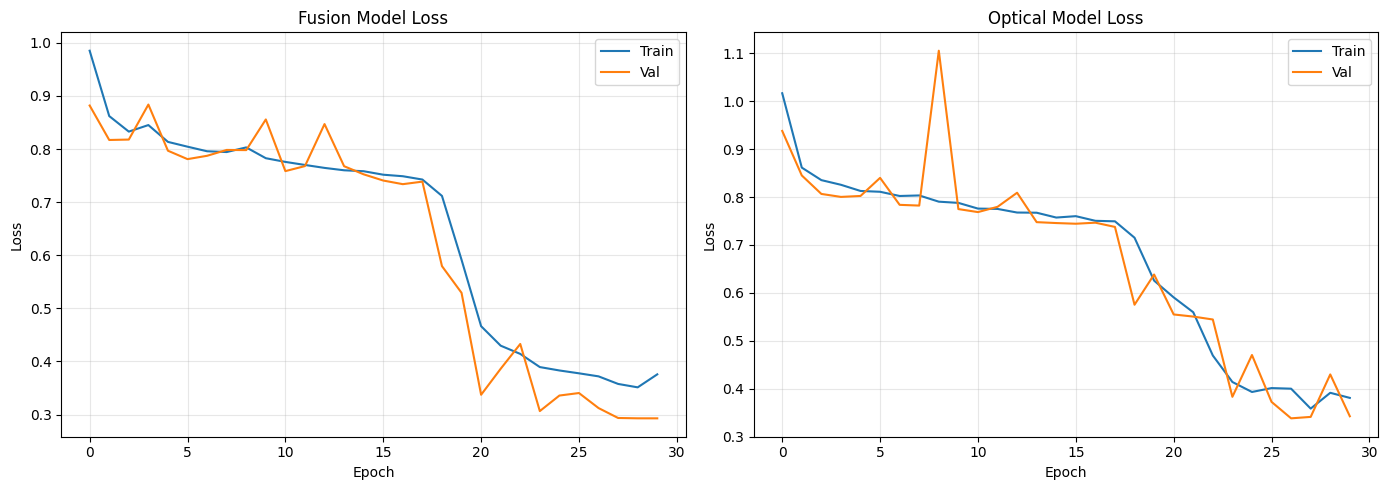

Figure saved: /content/drive/MyDrive/KZN_Research_Colab/Chapter4_Figures_4tile/training_curves_4tile.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fusion_history['train_loss'], label='Train')
axes[0].plot(fusion_history['val_loss'], label='Val')
axes[0].set_title('Fusion Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(optical_history['train_loss'], label='Train')
axes[1].plot(optical_history['val_loss'], label='Val')
axes[1].set_title('Optical Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR + 'training_curves_4tile.png', dpi=150)
plt.show()

print('Figure saved:', FIG_DIR + 'training_curves_4tile.png')

---
## Step 9: Summary

In [ ]:
print('=' * 65)
print('TRAINING COMPLETE')
print('=' * 65)
print(f'  Tiles            : 36JTM, 36JUM, 36JTN, 36JUN')
print(f'  Training patches : {len(train_ds_fusion):,}')
print(f'  Validation patches: {len(val_ds_fusion):,}')
print(f'  Test patches     : {len(test_ds_fusion):,}')
print()
print(f'  Fusion model  : {MODEL_DIR}fusion_unet_4tile_best.pt')
print(f'    F1={fusion_metrics["f1"]:.4f}  Kappa={fusion_metrics["kappa"]:.4f}  AUC={fusion_metrics["auc"]:.4f}')
print(f'  Optical model : {MODEL_DIR}optical_unet_4tile_best.pt')
print(f'    F1={optical_metrics["f1"]:.4f}  Kappa={optical_metrics["kappa"]:.4f}  AUC={optical_metrics["auc"]:.4f}')
print()


TRAINING COMPLETE
  Tiles            : 36JTM, 36JUM, 36JTN, 36JUN
  Training patches : 12,789
  Validation patches: 2,692
  Test patches     : 2,897

  Fusion model  : /content/drive/MyDrive/KZN_Research_Colab/Models_4tile/fusion_unet_4tile_best.pt
    F1=0.8443  Kappa=0.8378  AUC=0.9900
  Optical model : /content/drive/MyDrive/KZN_Research_Colab/Models_4tile/optical_unet_4tile_best.pt
    F1=0.8210  Kappa=0.8134  AUC=0.9852

